In [3]:
!pip install langchain langchain_core langchain_community langchain_openai langchain_text_splitters langchain-google-genai langgraph python-dotenv pypdf faiss-cpu transformers pydantic dotenv -q

## Sequential Workflow 

### BMI Workflow 

Let's start learning langGraph by making a small BMI Calc. Input -> Calc BMI -> Ouptut.

In [9]:
from langgraph.graph import StateGraph, START, END

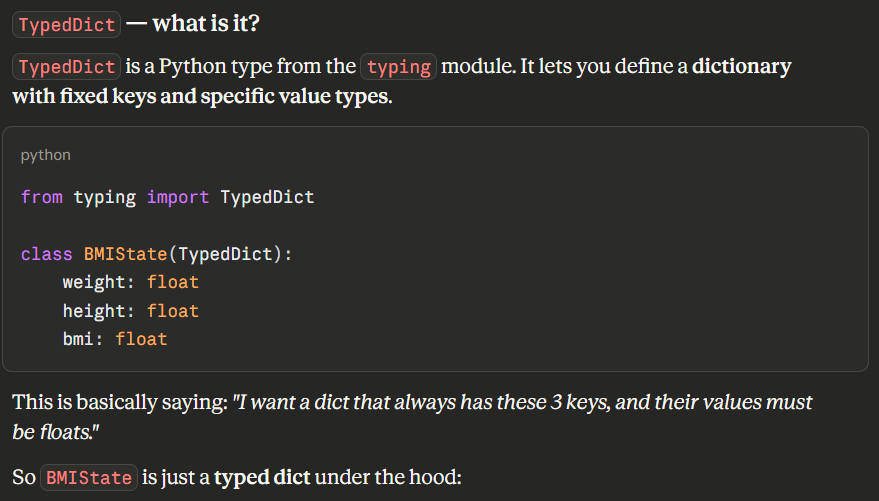
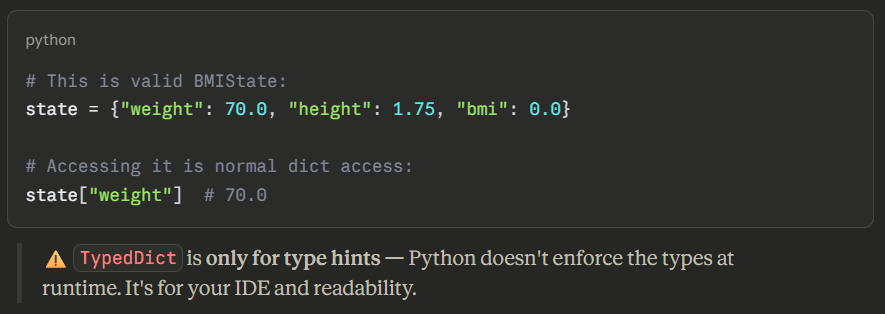

In [19]:
# step - 1 : Define the state of the graph
from typing import TypedDict

class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float
    overweight: str

# step - 2 : Create the graph
bmi_graph = StateGraph(BMIState)

def calculate_bmi(state: BMIState) -> BMIState:
    weight = state["weight"]
    height = state["height"]
    bmi = round(weight / (height ** 2), 2)

    state["bmi"] = bmi
    return state

def is_overweight(state: BMIState) -> BMIState:
    bmi = state["bmi"]
    state["overweight"] = "Yes" if bmi > 25 else "No"
    return state

# step - 3 : add nodes to the graph
bmi_graph.add_node("calculate_bmi", calculate_bmi)
bmi_graph.add_node("is_overweight", is_overweight)
                   

# step - 4 : add edges to the graph
bmi_graph.add_edge(START, "calculate_bmi")
bmi_graph.add_edge("calculate_bmi", "is_overweight")
bmi_graph.add_edge("is_overweight", END)

# step - 5 : compile the graph
workflow = bmi_graph.compile()

# step - 6 : invoke the graph with an initial state
initial_state = {
    "weight": 70,  # in kg  
    "height": 1.75  # in meters
}

output_state = workflow.invoke(initial_state)
output_state

{'weight': 70, 'height': 1.75, 'bmi': 22.86, 'overweight': 'No'}

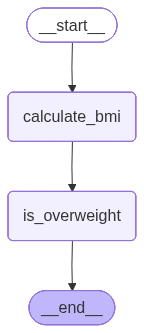

In [20]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

### LLM Based workflow

In [31]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv

# initialize the model and load environment variables
load_dotenv()

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash", 
    temperature=1.0,  
    max_tokens=None,
    timeout=None 
)

In [32]:
# create a state

class ChatState(TypedDict):
    question:str
    ans:str

# create a graph
llm_graph = StateGraph(ChatState)

# create node functions
def llm_question(state: ChatState) -> ChatState:
    question = state["question"]
    prompt = f'Answer the following question: {question}'
    answer = model.invoke(prompt).content
    state["ans"] = answer
    return state
   
# add nodes to the graph
llm_graph.add_node("llm_question", llm_question)

# add edges to the graph
llm_graph.add_edge(START, "llm_question")
llm_graph.add_edge("llm_question", END)

# compile the graph
llm_workflow = llm_graph.compile()

# invoke the graph with an initial state
initial_chat_state = {
    "question": "What is the capital of France?"
}
output_chat_state = llm_workflow.invoke(initial_chat_state)
output_chat_state

{'question': 'What is the capital of France?',
 'ans': 'The capital of France is **Paris**.'}